First 5 rows of the dataset:


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14



Checking for missing values:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 non-null  int64 
 1   Subject     33427 non-null  object
 2   Message     33345 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB
None

Summary Statistics:
          Message ID                               Subject  \
count   33716.000000                                 33427   
unique           NaN                                 24206   
top              NaN  schedule crawler : hourahead failure   
freq             NaN                                   185   
mean    16857.500000                                   NaN   
std      

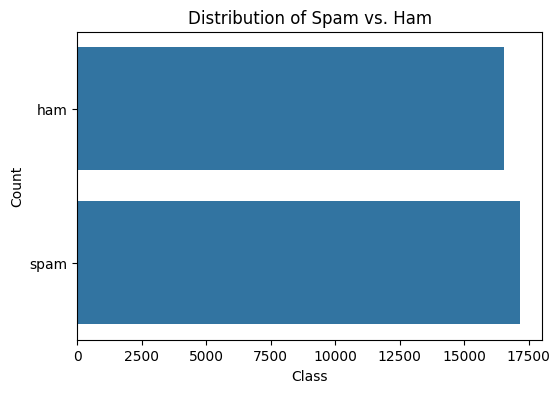

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Load the dataset
file_path = '/home/rd/Downloads/portfolio-main/enron_spam_data.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
print("First 5 rows of the dataset:")
display(data.head())

# Checking for missing values in each column
print("\nChecking for missing values:")
print(data.isnull().sum())

# Understanding the data types and basic statistics
print("\nDataset Information:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe(include='all'))

# Check the distribution of Spam and Ham classes
print("\nDistribution of Spam and Ham in the dataset:")
print(data['Spam/Ham'].value_counts())

# Visualizing the distribution of Spam vs. Ham
plt.figure(figsize=(6, 4))
sns.countplot(data['Spam/Ham'])
plt.title('Distribution of Spam vs. Ham')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


[nltk_data] Downloading package stopwords to /home/rd/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rd/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Preview of Cleaned Text Data:


,Subject,Message,Cleaned_Text
0,christmas tree farm pictures,NaN,christmas tree farm picture
1,"vastar resources , inc .","gary , production from the high island larger ...",vastar resource inc gary production high islan...
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,calpine daily gas nomination calpine daily gas...
3,re : issue,fyi - see note below - already done .\nstella\...,issue fyi see note already done stella forward...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,meter nov allocation fyi forwarded lauri allen...



Remaining Missing Values After Preprocessing:
Message ID        0
Subject         289
Message         371
Spam/Ham          0
Date              0
Text              0
Cleaned_Text      0
dtype: int64


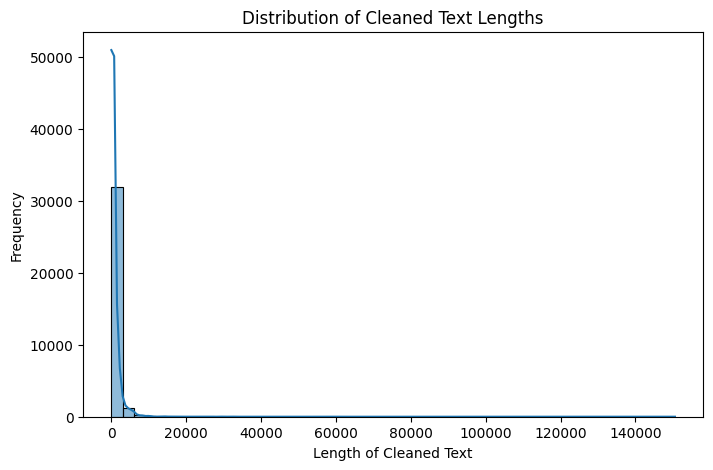

In [2]:
# Download NLTK resources for stopwords and lemmatization
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to clean and preprocess text
def preprocess_text(text):
    # Remove special characters, numbers, and extra spaces
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'\d', '', text)  # Remove digits
    text = text.lower()  # Convert to lowercase
    
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Join tokens back to a single string
    clean_text = ' '.join(tokens)
    return clean_text

# Combine 'Subject' and 'Message' columns into a single 'Text' column
data['Text'] = data['Subject'].fillna('') + ' ' + data['Message'].fillna('')

# Apply preprocessing to the 'Text' column
data['Cleaned_Text'] = data['Text'].apply(preprocess_text)

# Preview the cleaned text data
print("\nPreview of Cleaned Text Data:")
display(data[['Subject', 'Message', 'Cleaned_Text']].head())

# Check for any remaining missing values after preprocessing
print("\nRemaining Missing Values After Preprocessing:")
print(data.isnull().sum())

# Explore the length of the cleaned text to understand the range of email sizes
data['Text_Length'] = data['Cleaned_Text'].apply(len)

# Visualize the distribution of text lengths in the dataset
plt.figure(figsize=(8, 5))
sns.histplot(data['Text_Length'], bins=50, kde=True)
plt.title('Distribution of Cleaned Text Lengths')
plt.xlabel('Length of Cleaned Text')
plt.ylabel('Frequency')
plt.show()


In [3]:
# Import necessary library for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 features to manage memory and model complexity

# Fit and transform the cleaned text data to create TF-IDF features
X = tfidf_vectorizer.fit_transform(data['Cleaned_Text']).toarray()

# Extract the labels from the 'Spam/Ham' column
# Convert labels to binary format: 1 for spam, 0 for ham
data['Label'] = data['Spam/Ham'].apply(lambda x: 1 if x == 'spam' else 0)

# Separate labels into a different array
y = data['Label'].values

# Optional: Feature Engineering from the 'Date' column
# Extract year, month, and day as numerical features
data['Year'] = pd.to_datetime(data['Date']).dt.year
data['Month'] = pd.to_datetime(data['Date']).dt.month
data['Day'] = pd.to_datetime(data['Date']).dt.day

# Add the date features to the feature set if useful
additional_features = data[['Year', 'Month', 'Day']].to_numpy()

# Combine TF-IDF features with additional features (if added)
X = np.hstack((X, additional_features))

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (26972, 5003)
Shape of X_test: (6744, 5003)
Shape of y_train: (26972,)
Shape of y_test: (6744,)


In [4]:
# Import necessary libraries for model training and evaluation
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the classifiers
svm_classifier = SVC(kernel='linear', random_state=42)  # Linear kernel is effective for text classification
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)  # Using 100 trees in the forest

# Train the SVM Classifier
print("Training SVM Classifier...")
svm_classifier.fit(X_train, y_train)

# Train the Random Forest Classifier
print("Training Random Forest Classifier...")
rf_classifier.fit(X_train, y_train)

# Predict on the test set using SVM Classifier
print("\nEvaluating SVM Classifier...")
svm_pred = svm_classifier.predict(X_test)

# Predict on the test set using Random Forest Classifier
print("\nEvaluating Random Forest Classifier...")
rf_pred = rf_classifier.predict(X_test)

# Evaluation Metrics for SVM
print("\nSVM Classifier Evaluation Metrics:")
print(classification_report(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("Accuracy Score:", accuracy_score(y_test, svm_pred))

# Evaluation Metrics for Random Forest
print("\nRandom Forest Classifier Evaluation Metrics:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Accuracy Score:", accuracy_score(y_test, rf_pred))


Training SVM Classifier...
Training Random Forest Classifier...

Evaluating SVM Classifier...

Evaluating Random Forest Classifier...

SVM Classifier Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3276
           1       1.00      1.00      1.00      3468

    accuracy                           1.00      6744
   macro avg       1.00      1.00      1.00      6744
weighted avg       1.00      1.00      1.00      6744

Confusion Matrix:
 [[3276    0]
 [   8 3460]]
Accuracy Score: 0.9988137603795967

Random Forest Classifier Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3276
           1       1.00      1.00      1.00      3468

    accuracy                           1.00      6744
   macro avg       1.00      1.00      1.00      6744
weighted avg       1.00      1.00      1.00      6744

Confusion Matrix:
 [[3274    2]
 [   2 3466]]
Acc

In [1]:
# Function to add additional features to the TF-IDF vector
def add_additional_features(vector, date_features):
    """
    Combines the TF-IDF vector with additional date-based features.

    Parameters:
    - vector: TF-IDF vector (numpy array)
    - date_features: Additional features (numpy array)

    Returns:
    - Combined feature vector
    """
    return np.hstack((vector, date_features))

# Function to classify a new email as spam or ham
def classify_email(subject, message, svm_model, rf_model, vectorizer):
    """
    Classifies an email as spam or ham using trained SVM and Random Forest models.
    """
    # Combine subject and message to form a single text input
    combined_text = subject + ' ' + message

    # Preprocess the combined text
    clean_text = preprocess_text(combined_text)

    # Transform the cleaned text to TF-IDF vector
    text_vector = vectorizer.transform([clean_text]).toarray()

    # Here, we simulate extracting date features (for consistency, use placeholders or extract actual features)
    # Assuming year=2024, month=9, day=7 for this example
    date_features = np.array([[2024, 9, 7]])

    # Combine TF-IDF vector with additional features
    text_vector = add_additional_features(text_vector, date_features)

    # Predict using SVM model
    svm_prediction = svm_model.predict(text_vector)
    # Predict using Random Forest model
    rf_prediction = rf_model.predict(text_vector)

    # Convert numerical prediction back to 'spam' or 'ham'
    svm_result = 'spam' if svm_prediction[0] == 1 else 'ham'
    rf_result = 'spam' if rf_prediction[0] == 1 else 'ham'

    return svm_result, rf_result

# User input loop for testing the classifier with new email examples
print("Enter the subject and message of an email to classify it as 'spam' or 'ham'. Type 'exit' to stop.")

while True:
    subject = input("Enter email subject: ")
    if subject.lower() == 'exit':
        break
    message = input("Enter email message: ")
    if message.lower() == 'exit':
        break

    # Ensure both models and vectorizer are loaded correctly
    if 'svm_classifier' in globals() and 'rf_classifier' in globals() and 'tfidf_vectorizer' in globals():
        try:
            # Predict and display results for the user-entered email
            svm_result, rf_result = classify_email(subject, message, svm_classifier, rf_classifier, tfidf_vectorizer)
            print(f"Subject: {subject}")
            print(f"SVM Prediction: {svm_result}, Random Forest Prediction: {rf_result}")
            print('-' * 50)
        except ValueError as e:
            print(f"Error: {e}")
    else:
        print("Models or vectorizer are not initialized correctly.")
        break


Enter the subject and message of an email to classify it as 'spam' or 'ham'. Type 'exit' to stop.
Models or vectorizer are not initialized correctly.
